#Marketing Campaign Attribution

**Domain:** Marketing Analytics

**Dataset:** Marketing Campaign Dataset -- https://www.kaggle.com/datasets/jackdaoud/marketing-data

**Skills:** Marketing Analytics, Attribution Modeling, ROI Analysis, Data-Driven Decision Making

**Tools:** Python, Pandas, Matplotlib, Power BI/Tableau

---

### Problem Statement
A company runs campaigns across social, search, email, and paid ads but doesn't know which channel actually drives conversions. Leadership wants a data-backed answer on where to shift next quarter's budget.



In [1]:
!pip install -q kagglehub

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)

        # the exact filename/path we expect doesn't always match what kaggle actually gives us
        # (nested folders, versioned paths, slightly different casing) -- if our guess isn't
        # there, look for any CSV in the download instead of giving up and going to synthetic data
        if not os.path.exists(full_path):
            csv_candidates = []
            for root, _dirs, files in os.walk(path):
                for fname in files:
                    if fname.lower().endswith('.csv'):
                        csv_candidates.append(os.path.join(root, fname))
            if csv_candidates:
                csv_candidates.sort(key=lambda p: 0 if csv_name.lower() in p.lower() else 1)
                full_path = csv_candidates[0]
                print(f"expected file not found at that exact path, using closest match instead: {os.path.basename(full_path)}")
            else:
                raise FileNotFoundError(f"no CSV files found anywhere in the downloaded dataset at {path}")

        # not every kaggle CSV is UTF-8 -- try that first, then fall back to latin-1/ISO-8859-1
        # instead of treating any decode error as a total failure and going to synthetic data
        try:
            df = pd.read_csv(full_path)
        except UnicodeDecodeError:
            df = pd.read_csv(full_path, encoding='ISO-8859-1')

        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_marketing(n_rows=2000):
    # matches the REAL jackdaoud/marketing-data columns (it's a customer + campaign response
    # dataset, not a simple channel log, so we're faking the same shape here)
    np.random.seed(7)
    income = np.round(np.random.normal(52000, 20000, n_rows).clip(10000, 150000), 2)
    web = np.random.poisson(4, n_rows)
    catalog = np.random.poisson(2, n_rows)
    store = np.random.poisson(5, n_rows)
    deals = np.random.poisson(2, n_rows)
    return pd.DataFrame({
        'ID': range(1, n_rows + 1), 'Income': income,
        'NumWebPurchases': web, 'NumCatalogPurchases': catalog,
        'NumStorePurchases': store, 'NumDealsPurchases': deals,
        'AcceptedCmp1': np.random.binomial(1, 0.07, n_rows), 'AcceptedCmp2': np.random.binomial(1, 0.05, n_rows),
        'AcceptedCmp3': np.random.binomial(1, 0.07, n_rows), 'AcceptedCmp4': np.random.binomial(1, 0.07, n_rows),
        'AcceptedCmp5': np.random.binomial(1, 0.07, n_rows), 'Response': np.random.binomial(1, 0.15, n_rows),
    })

### Step 1: Load Data -- This Dataset Is Customer-Level, One Row Per Customer, With Purchase

In [3]:
# 1. LOAD DATA -- this dataset is customer-level, one row per customer, with purchase
# counts per channel (web/catalog/store) and whether they accepted each past campaign
df = load_dataset_safe('jackdaoud/marketing-data', 'marketing_data.csv', make_fake_marketing)
df.columns = [c.strip() for c in df.columns]
# some kaggle mirrors put a $ sign and spaces in Income, cleaning that up just in case
if df['Income'].dtype == object:
    df['Income'] = df['Income'].astype(str).str.replace(r'[$, ]', '', regex=True)
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df = df.dropna(subset=['Income'])

Using Colab cache for faster access to the 'marketing-data' dataset.
expected file not found at that exact path, using closest match instead: ifood_df.csv
loaded real dataset from kaggle, 2205 rows


### Step 2: Treat Each Purchase Channel Like A "Channel" We Can Compare

In [4]:
# 2. TREAT EACH PURCHASE CHANNEL LIKE A "CHANNEL" WE CAN COMPARE
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
channel_totals = df[channel_cols].sum().sort_values(ascending=False)
channel_share = (channel_totals / channel_totals.sum() * 100).round(1)
print("purchases by channel:\n", channel_totals)
print("\n% share by channel:\n", channel_share)

purchases by channel:
 NumStorePurchases      12841
NumWebPurchases         9042
NumCatalogPurchases     5833
NumDealsPurchases       5112
dtype: int64

% share by channel:
 NumStorePurchases      39.1
NumWebPurchases        27.5
NumCatalogPurchases    17.8
NumDealsPurchases      15.6
dtype: float64


### Step 3: How Well Did Each Past Campaign Do

In [5]:
# 3. HOW WELL DID EACH PAST CAMPAIGN DO (this is our "attribution" -- which campaign actually
# got people to say yes)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_acceptance = df[campaign_cols].mean().sort_values(ascending=False) * 100
print("\ncampaign acceptance rate (%):\n", campaign_acceptance.round(2))


campaign acceptance rate (%):
 Response        15.10
AcceptedCmp4     7.44
AcceptedCmp3     7.39
AcceptedCmp5     7.30
AcceptedCmp1     6.44
AcceptedCmp2     1.36
dtype: float64


### Step 4: Does Higher Income Mean More Online Purchases Or More In-Store?

In [6]:
# 4. DOES HIGHER INCOME MEAN MORE ONLINE PURCHASES OR MORE IN-STORE? (simple roi-style comparison)
income_bracket = pd.qcut(df['Income'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
channel_by_income = df.groupby(income_bracket)[channel_cols].mean()
print("\navg purchases per channel by income bracket:\n", channel_by_income)


avg purchases per channel by income bracket:
           NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
Income                                                              
Low              2.010850             0.475588           2.960217   
Mid-Low          3.385455             1.156364           4.212727   
Mid-High         5.629764             3.310345           7.658802   
High             5.382940             5.644283           8.470054   

          NumDealsPurchases  
Income                       
Low                2.057866  
Mid-Low            2.765455  
Mid-High           3.070780  
High               1.381125  


/tmp/ipykernel_1351/3738868621.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_by_income = df.groupby(income_bracket)[channel_cols].mean()


### Step 5: Charts

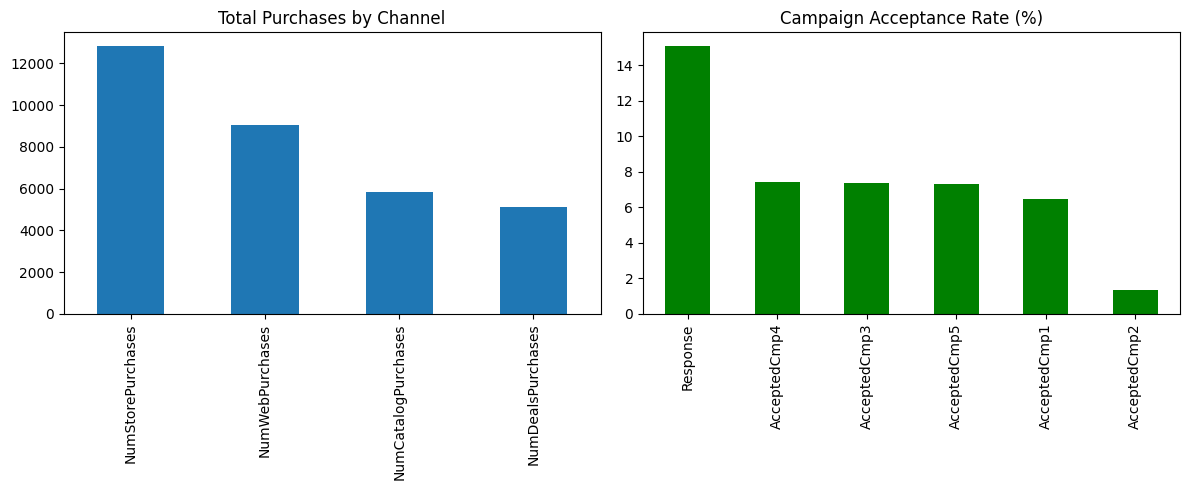

In [7]:
# 5. CHARTS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
channel_totals.plot(kind='bar', ax=axes[0], title='Total Purchases by Channel')
campaign_acceptance.plot(kind='bar', ax=axes[1], title='Campaign Acceptance Rate (%)', color='green')
plt.tight_layout()
plt.savefig('channel_performance.png')
plt.show()

### Step 6: Save

In [8]:
# 6. SAVE
channel_totals.to_csv('channel_totals.csv')
campaign_acceptance.to_csv('campaign_acceptance.csv')
channel_by_income.to_csv('channel_by_income_bracket.csv')